# CMAPSS - Exploratory Data Analysis
**Arkon Manufacturing AI | Module: Time Series | Department: Engine Testing**

NASA CMAPSS (Commercial Modular Aero-Propulsion System Simulation) dataset.
Contains run-to-failure sensor data from turbofan engines across 4 sub-datasets (FD001–FD004).

**Goal:** Understand the data structure, sensor behaviour, and engine degradation patterns
before building a Remaining Useful Life (RUL) prediction model.

---
| Sub-dataset | Operating Conditions | Fault Modes |
|-------------|---------------------|-------------|
| FD001       | 1                   | 1           |
| FD002       | 6                   | 1           |
| FD003       | 1                   | 2           |
| FD004       | 6                   | 2           |

We start with **FD001** - the simplest case.

In [1]:
import sys
from pathlib import Path

# Add notebooks/utils to path (works on Mac, Windows, Linux)
_nb_root = Path('..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import (
    get_device, get_mlflow_uri, save_figure,
    Timer, CheckpointManager, recommended_num_workers
)

print('arkon_utils loaded ✓')

arkon_utils loaded ✓


## 1. Imports & Configuration

In [2]:
# Import all libraries needed for data loading and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Assets subfolder for this module
ASSETS = 'timeseries'


## 2. Column Names

In [3]:
# Define column names manually - CMAPSS files have no header row
COLUMNS = [
    'unit',           # engine unit number (1 engine = 1 run-to-failure)
    'cycle',          # operational cycle number (time step)
    'os_1', 'os_2', 'os_3',   # 3 operational settings
    's1',  's2',  's3',  's4',  's5',  's6',  's7',
    's8',  's9',  's10', 's11', 's12', 's13', 's14',
    's15', 's16', 's17', 's18', 's19', 's20', 's21'  # 21 sensor measurements
]
print(f'Total columns: {len(COLUMNS)}')

Total columns: 26


## 3. Load Data

In [4]:
DATA_DIR   = Path('../../data/01_cmapss/raw/CMaps')
assert DATA_DIR.exists(), f'Data not found: {DATA_DIR}'
print(f'Data dir: {DATA_DIR}')


Data dir: ..\..\data\01_cmapss\raw\CMaps


In [5]:
# Load FD001 train/test and true RUL labels
df_train = pd.read_csv(DATA_DIR / 'train_FD001.txt', sep=r'\s+', header=None, names=COLUMNS)
df_test  = pd.read_csv(DATA_DIR / 'test_FD001.txt',  sep=r'\s+', header=None, names=COLUMNS)
df_rul   = pd.read_csv(DATA_DIR / 'RUL_FD001.txt',   header=None, names=['RUL'])

print(f'Train shape: {df_train.shape}')
print(f'Test shape:  {df_test.shape}')
print(f'RUL shape:   {df_rul.shape}')

Train shape: (20631, 26)


Test shape:  (13096, 26)
RUL shape:   (100, 1)


## 4. First Look

In [6]:
# Show the first 5 rows to understand the data structure
df_train.head()

,unit,cycle,os_1,os_2,os_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
# Show data types and memory usage - check for unexpected types
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   unit    20631 non-null  int64  
 1   cycle   20631 non-null  int64  
 2   os_1    20631 non-null  float64
 3   os_2    20631 non-null  float64
 4   os_3    20631 non-null  float64
 5   s1      20631 non-null  float64
 6   s2      20631 non-null  float64
 7   s3      20631 non-null  float64
 8   s4      20631 non-null  float64
 9   s5      20631 non-null  float64
 10  s6      20631 non-null  float64
 11  s7      20631 non-null  float64
 12  s8      20631 non-null  float64
 13  s9      20631 non-null  float64
 14  s10     20631 non-null  float64
 15  s11     20631 non-null  float64
 16  s12     20631 non-null  float64
 17  s13     20631 non-null  float64
 18  s14     20631 non-null  float64
 19  s15     20631 non-null  float64
 20  s16     20631 non-null  float64
 21  s17     20631 non-null  int64  
 22

In [8]:
# Check basic statistics - min, max, mean, std for each column
df_train.describe().round(2)

,unit,cycle,os_1,os_2,os_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
count,20631.00,20631.00,20631.00,20631.0,20631.0,20631.00,20631.00,20631.00,20631.00,20631.00,...,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.0,20631.0,20631.00,20631.00
mean,51.51,108.81,-0.00,0.0,100.0,518.67,642.68,1590.52,1408.93,14.62,...,521.41,2388.10,8143.75,8.44,0.03,393.21,2388.0,100.0,38.82,23.29
std,29.23,68.88,0.00,0.0,0.0,0.00,0.50,6.13,9.00,0.00,...,0.74,0.07,19.08,0.04,0.00,1.55,0.0,0.0,0.18,0.11
min,1.00,1.00,-0.01,-0.0,100.0,518.67,641.21,1571.04,1382.25,14.62,...,518.69,2387.88,8099.94,8.32,0.03,388.00,2388.0,100.0,38.14,22.89
25%,26.00,52.00,-0.00,-0.0,100.0,518.67,642.33,1586.26,1402.36,14.62,...,520.96,2388.04,8133.24,8.41,0.03,392.00,2388.0,100.0,38.70,23.22
50%,52.00,104.00,0.00,0.0,100.0,518.67,642.64,1590.10,1408.04,14.62,...,521.48,2388.09,8140.54,8.44,0.03,393.00,2388.0,100.0,38.83,23.30
75%,77.00,156.00,0.00,0.0,100.0,518.67,643.00,1594.38,1414.55,14.62,...,521.95,2388.14,8148.31,8.47,0.03,394.00,2388.0,100.0,38.95,23.37
max,100.00,362.00,0.01,0.0,100.0,518.67,644.53,1616.91,1441.49,14.62,...,523.38,2388.56,8293.72,8.58,0.03,400.00,2388.0,100.0,39.43,23.62


## 5. Missing Values

In [9]:
# Check for missing values - CMAPSS should have none, but always verify
missing = df_train.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values ✓')

Missing values per column:
No missing values ✓


## 6. How Many Engines?

In [10]:
# Count number of unique engines and their operational lifetimes in cycles
n_engines_train = df_train['unit'].nunique()
n_engines_test  = df_test['unit'].nunique()

print(f'Engines in training set: {n_engines_train}')
print(f'Engines in test set:     {n_engines_test}')

# Show max cycle (lifespan) per engine in training set
engine_life = df_train.groupby('unit')['cycle'].max().sort_values()
print(f'\nEngine lifetime (cycles):')
print(f'  Min: {engine_life.min()}')
print(f'  Max: {engine_life.max()}')
print(f'  Mean: {engine_life.mean():.1f}')

Engines in training set: 100
Engines in test set:     100

Engine lifetime (cycles):
  Min: 128
  Max: 362
  Mean: 206.3


## 7. Engine Lifetime Distribution

  ✓ Saved → assets\timeseries\cmapss_eda_engine_lifetime.png


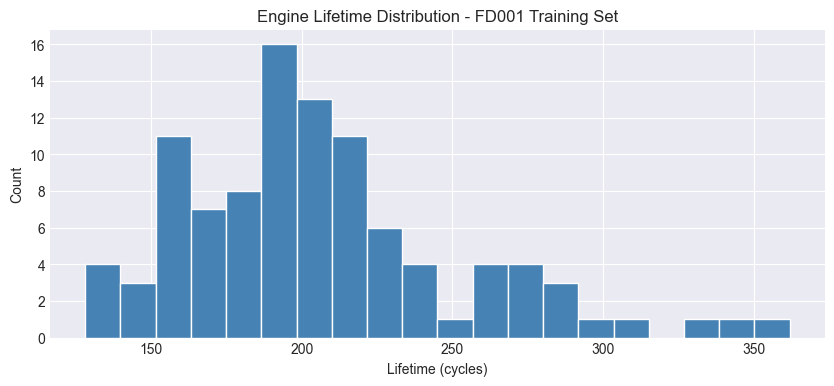

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
engine_life.plot(kind='hist', bins=20, ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Lifetime (cycles)')
ax.set_ylabel('Count')
ax.set_title('Engine Lifetime Distribution - FD001 Training Set')
save_figure(fig, 'cmapss_eda_engine_lifetime', subfolder=ASSETS)
plt.show()


## 8. Sensor Degradation Over Time

  ✓ Saved → assets\timeseries\cmapss_eda_sensor_degradation.png


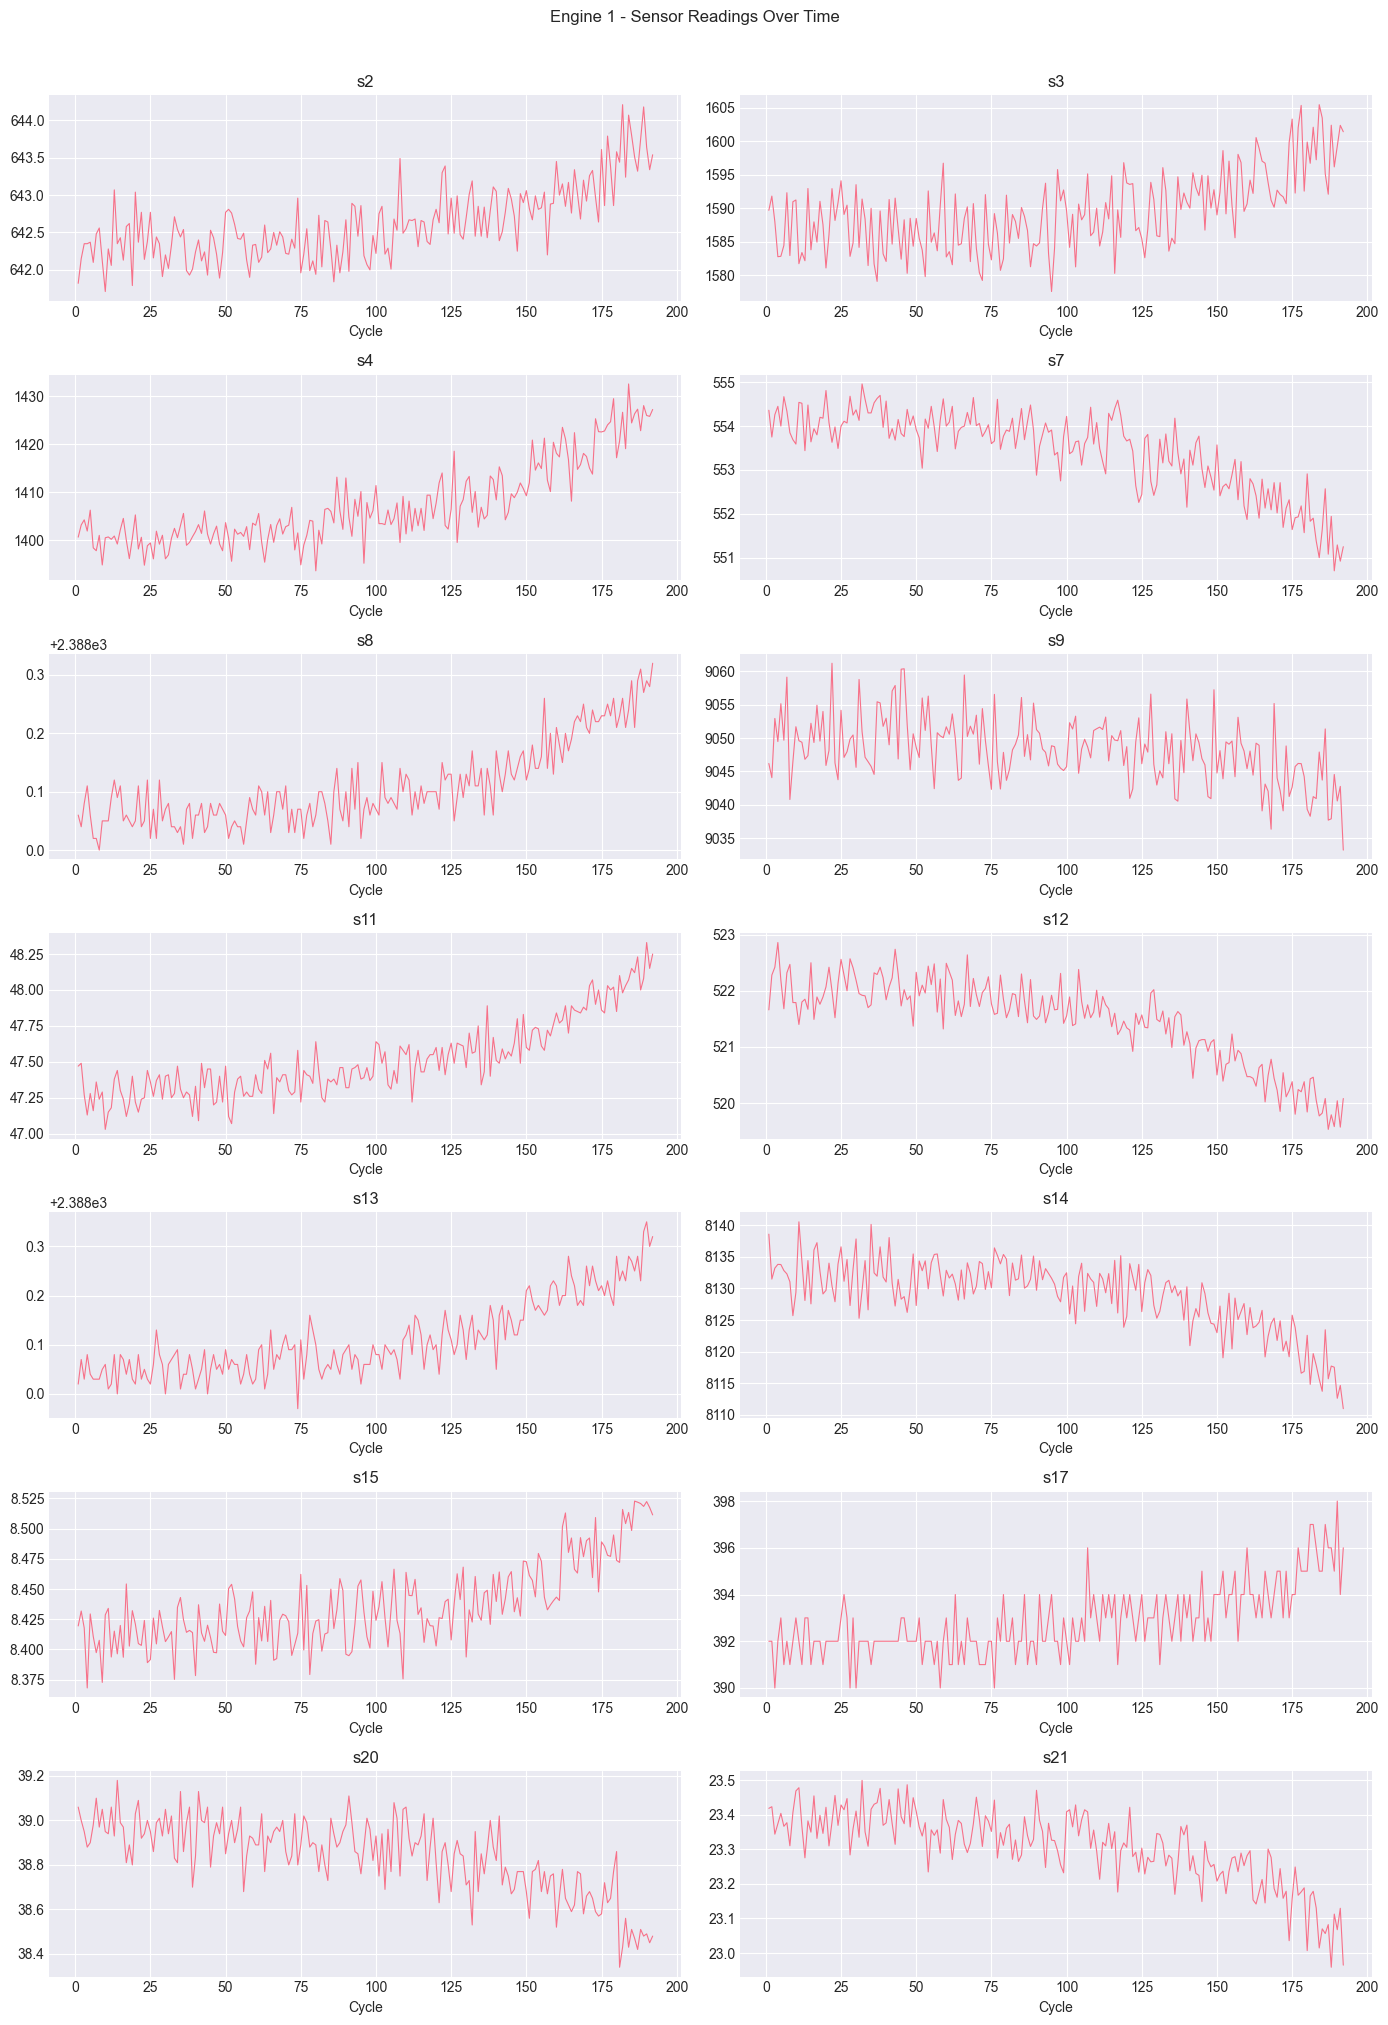

In [12]:
SENSORS = ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
engine_id = 1

engine_data = df_train[df_train['unit'] == engine_id]
fig, axes = plt.subplots(len(SENSORS)//2, 2, figsize=(14, 20))
axes = axes.flatten()
for i, sensor in enumerate(SENSORS):
    axes[i].plot(engine_data['cycle'], engine_data[sensor], linewidth=0.8)
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Cycle')
plt.suptitle(f'Engine {engine_id} - Sensor Readings Over Time', y=1.01)
plt.tight_layout()
save_figure(fig, 'cmapss_eda_sensor_degradation', subfolder=ASSETS)
plt.show()


## 9. Constant Sensors (Zero Variance)

In [13]:
# Identify sensors with zero or near-zero variance - they carry no useful information
sensor_cols = [c for c in COLUMNS if c.startswith('s')]
variances = df_train[sensor_cols].var()

flat_sensors = variances[variances < 0.01].index.tolist()
useful_sensors = variances[variances >= 0.01].index.tolist()

print(f'Flat (useless) sensors: {flat_sensors}')
print(f'\nUseful sensors ({len(useful_sensors)}): {useful_sensors}')

Flat (useless) sensors: ['s1', 's5', 's6', 's8', 's10', 's13', 's15', 's16', 's18', 's19']

Useful sensors (11): ['s2', 's3', 's4', 's7', 's9', 's11', 's12', 's14', 's17', 's20', 's21']


## 10. Correlation Heatmap

  ✓ Saved → assets\timeseries\cmapss_eda_correlation_heatmap.png


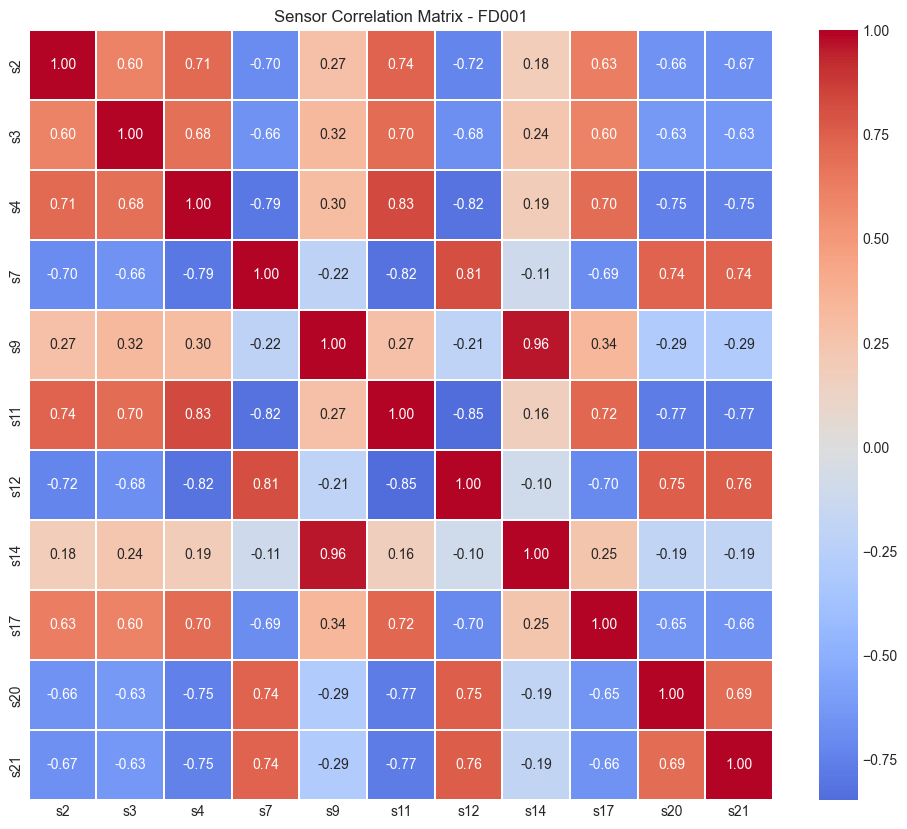

In [14]:
fig, ax = plt.subplots(figsize=(12, 10))
corr = df_train[useful_sensors].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.3, ax=ax)
ax.set_title('Sensor Correlation Matrix - FD001')
save_figure(fig, 'cmapss_eda_correlation_heatmap', subfolder=ASSETS)
plt.show()


## 11. Compare All 4 Sub-datasets

In [15]:
# Load all 4 FD datasets to compare their size and complexity
datasets = {}
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    datasets[fd] = pd.read_csv(
        DATA_DIR / f'train_{fd}.txt',
        sep=r'\s+', header=None, names=COLUMNS
    )

# Print summary statistics for each sub-dataset
print(f'{"Dataset":<8} {"Engines":<10} {"Total rows":<12} {"Max cycles":<12}')
print('-' * 45)
for name, df in datasets.items():
    n_eng = df['unit'].nunique()
    n_rows = len(df)
    max_cyc = df.groupby('unit')['cycle'].max().max()
    print(f'{name:<8} {n_eng:<10} {n_rows:<12} {max_cyc:<12}')

Dataset  Engines    Total rows   Max cycles  
---------------------------------------------
FD001    100        20631        362         
FD002    260        53759        378         
FD003    100        24720        525         
FD004    249        61249        543         


## 12. Multi-engine Degradation Plot

  ✓ Saved → assets\timeseries\cmapss_eda_multiengine_degradation.png

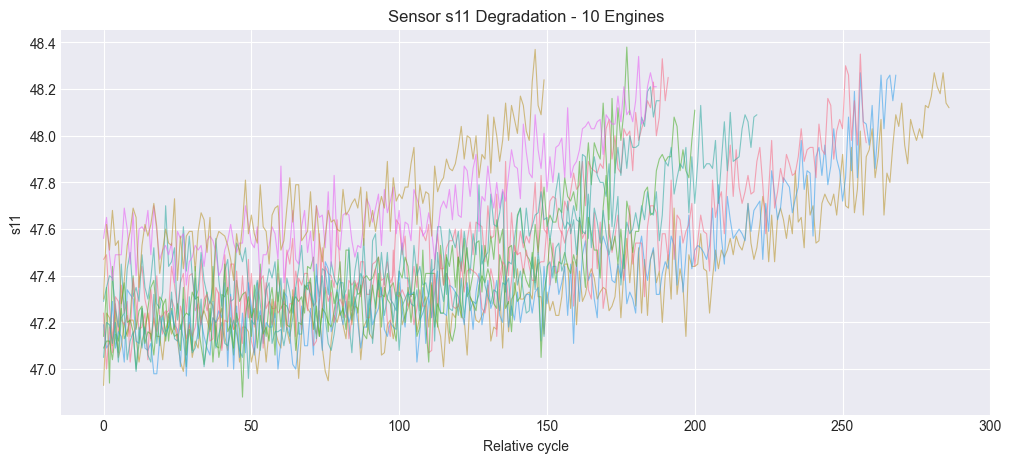

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
sample_engines = df_train['unit'].unique()[:10]
for eng in sample_engines:
    eng_data = df_train[df_train['unit'] == eng]
    ax.plot(range(len(eng_data)), eng_data['s11'], alpha=0.6, linewidth=0.8)
ax.set_xlabel('Relative cycle')
ax.set_ylabel('s11')
ax.set_title('Sensor s11 Degradation - 10 Engines')
save_figure(fig, 'cmapss_eda_multiengine_degradation', subfolder=ASSETS)
plt.show()


## 13. Key EDA Findings

| Finding | Detail |
|---------|--------|
| No missing values | Dataset is clean |
| 100 engines in FD001 train | Each runs to failure |
| Several flat sensors | s1, s5, s6, s10, s16, s18, s19 - drop in preprocessing |
| Clear degradation trends | Sensors s11, s12, s13, s14, s17, s21 show strong signal |
| Variable engine lifetime | 128–362 cycles - model must handle variable-length sequences |

**Next step:** `02_cmapss_preprocessing.ipynb` - add RUL labels, drop flat sensors, normalise.